In [ ]:
! pip install langgraph langchain-anthropic langchain-core langchain-community dotenv

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [73]:
from typing import Annotated, TypedDict
from langgraph.graph import StateGraph, END
import dotenv
from langchain_core.messages import AnyMessage, SystemMessage, HumanMessage, ToolMessage
from langchain_anthropic import ChatAnthropic
from langchain_community.tools.tavily_search import TavilySearchResults
import operator
import json


In [39]:
dotenv.load_dotenv()

True

In [40]:
tool = TavilySearchResults(max_results=4)
print(tool)

max_results=4 api_wrapper=TavilySearchAPIWrapper(tavily_api_key=SecretStr('**********'))


In [41]:
tool.__dict__

{'name': 'tavily_search_results_json',
 'description': 'A search engine optimized for comprehensive, accurate, and trusted results. Useful for when you need to answer questions about current events. Input should be a search query.',
 'args_schema': langchain_community.tools.tavily_search.tool.TavilyInput,
 'return_direct': False,
 'verbose': False,
 'callbacks': None,
 'tags': None,
 'metadata': None,
 'handle_tool_error': False,
 'handle_validation_error': False,
 'response_format': 'content_and_artifact',
 'extras': None,
 'max_results': 4,
 'search_depth': 'advanced',
 'include_domains': [],
 'exclude_domains': [],
 'include_answer': False,
 'include_raw_content': False,
 'include_images': False,
 'api_wrapper': TavilySearchAPIWrapper(tavily_api_key=SecretStr('**********'))}

In [54]:
class AgentState(TypedDict):
    messages: Annotated[list[AnyMessage],operator.add]

In [74]:
class Agent:

    def __init__(self,model,tools,system=""):
        self.system = system

        graph = StateGraph(AgentState)
        graph.add_node("llm",self.call_anthropic)
        graph.add_node("action",self.take_action)
        graph.add_conditional_edges("llm",self.exists_action,{True:"action",False:END})
        graph.add_edge("action","llm")

        graph.set_entry_point("llm")
        self.graph = graph.compile()
        self.tools = {t.name: t for t in tools}
        self.model = model.bind_tools(tools)


    def exists_action(self,state:AgentState):
        return len(state["messages"][-1].tool_calls) > 0

    def call_anthropic(self,state:AgentState):
        messages = state['messages']
        if self.system:
            messages = [SystemMessage(content=self.system)] + messages
        message = self.model.invoke(messages)
        return {"messages":[message]}
        
    def take_action(self,state:AgentState):
        tool_calls = state["messages"][-1].tool_calls
        results = []
        for t in tool_calls:
            print(f"Calling: {t}")
            if t["name"] not in self.tools:
                print("\n ....bad tool name....")
                result = "bad tool name, retry"
            else:
                result = self.tools[t["name"]].invoke(t["args"])
            content_str = json.dumps(result) if isinstance(result,(list,dict)) else str(result)
            results.append(ToolMessage(tool_call_id=t['id'],name=t["name"],content=content_str))
            print("Back to the model!")
        return {'messages': results}

In [75]:
prompt = """You are a smart research assistant. Use the search engine to look up information. \
You are allowed to make multiple calls (either together or in sequence). \
Only look up information when you are sure of what you want. \
If you need to look up some information before asking a follow up question, you are allowed to do that!
"""

model = ChatAnthropic(model_name="claude-opus-4-8")

In [76]:
abot = Agent(model,[tool],system=prompt)

In [77]:
! pip install pygraphviz

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


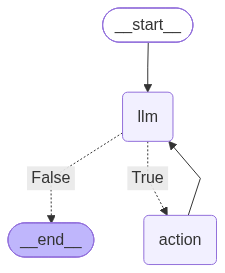

In [78]:
from IPython.display import Image, display
display(Image(abot.graph.get_graph().draw_mermaid_png()))

In [79]:
messages = [HumanMessage(content="What is the weather in sf?")]
result = abot.graph.invoke({"messages": messages})

Calling: {'name': 'tavily_search_results_json', 'args': {'query': 'current weather in San Francisco'}, 'id': 'toolu_01UXirkLzijPB51s8CuVxR1N', 'type': 'tool_call'}
Back to the model!


In [80]:
result

{'messages': [HumanMessage(content='What is the weather in sf?', additional_kwargs={}, response_metadata={}),
  AIMessage(content=[{'text': "I'll search for the current weather in San Francisco for you.", 'type': 'text'}, {'id': 'toolu_01UXirkLzijPB51s8CuVxR1N', 'caller': {'type': 'direct'}, 'input': {'query': 'current weather in San Francisco'}, 'name': 'tavily_search_results_json', 'type': 'tool_use'}], additional_kwargs={}, response_metadata={'id': 'msg_011CdKaya9x4JU389yR26w4T', 'container': None, 'model': 'claude-opus-4-8', 'stop_details': None, 'stop_reason': 'tool_use', 'stop_sequence': None, 'usage': {'cache_creation': {'ephemeral_1h_input_tokens': 0, 'ephemeral_5m_input_tokens': 0}, 'cache_creation_input_tokens': 0, 'cache_read_input_tokens': 0, 'inference_geo': 'global', 'input_tokens': 514, 'output_tokens': 80, 'output_tokens_details': {'thinking_tokens': 0}, 'server_tool_use': None, 'service_tier': 'standard'}, 'model_name': 'claude-opus-4-8', 'model_provider': 'anthropic'}

In [82]:
result["messages"][-1].content

"Here's the current weather in San Francisco:\n\n**Today (July 22):** Partly cloudy with a high of 21°C (70°F) and a low of 15°C (59°F). Winds around 22 km/h, humidity at 88%.\n\n**Hourly outlook:**\n- **Morning:** Cool and humid, around 14-15°C (57-59°F)\n- **Afternoon:** Warmest around 19°C (66°F), with breezy winds picking up to ~23 km/h\n- **Evening:** Cooling back down to 15-16°C (59-61°F)\n\n**Tomorrow (July 23):** Sunny with a high of 19°C (66°F) and a low of 14°C (57°F).\n\nOverall, it's typical San Francisco summer weather—mild, dry, and a bit breezy. You might want to bring a light jacket, especially for the cooler mornings and evenings! 🌉"

In [83]:
messages = [HumanMessage(content="What is the weather in SF and LA?")]
result = abot.graph.invoke({"messages": messages})

Calling: {'name': 'tavily_search_results_json', 'args': {'query': 'current weather in San Francisco'}, 'id': 'toolu_012gZUbPy4kQjxfvTNSwRgfR', 'type': 'tool_call'}
Back to the model!
Calling: {'name': 'tavily_search_results_json', 'args': {'query': 'current weather in Los Angeles'}, 'id': 'toolu_0186Wsqv6EuKsHyBgiAHC5gH', 'type': 'tool_call'}
Back to the model!


In [84]:
result

{'messages': [HumanMessage(content='What is the weather in SF and LA?', additional_kwargs={}, response_metadata={}),
  AIMessage(content=[{'text': "I'll look up the current weather for both San Francisco and Los Angeles.", 'type': 'text'}, {'id': 'toolu_012gZUbPy4kQjxfvTNSwRgfR', 'caller': {'type': 'direct'}, 'input': {'query': 'current weather in San Francisco'}, 'name': 'tavily_search_results_json', 'type': 'tool_use'}, {'id': 'toolu_0186Wsqv6EuKsHyBgiAHC5gH', 'caller': {'type': 'direct'}, 'input': {'query': 'current weather in Los Angeles'}, 'name': 'tavily_search_results_json', 'type': 'tool_use'}], additional_kwargs={}, response_metadata={'id': 'msg_011CdKb7vSos244UPy9dTQEd', 'container': None, 'model': 'claude-opus-4-8', 'stop_details': None, 'stop_reason': 'tool_use', 'stop_sequence': None, 'usage': {'cache_creation': {'ephemeral_1h_input_tokens': 0, 'ephemeral_5m_input_tokens': 0}, 'cache_creation_input_tokens': 0, 'cache_read_input_tokens': 0, 'inference_geo': 'global', 'input

In [85]:
result["messages"][-1].content

"Here's the current weather for both cities:\n\n## San Francisco, CA ☁️\n- **Temperature:** ~21°C / 70°F (high), 15°C / 59°F (low)\n- **Conditions:** Partly cloudy to sunny\n- **Humidity:** ~88%\n- **Wind:** ~22 km/h\n- Cool and comfortable, with typical foggy/breezy coastal weather. Dress in layers!\n\n## Los Angeles, CA ☀️\n- **Temperature:** ~32°C / 90°F (high), 19°C / 66°F (low)\n- **Conditions:** Sunny and dry\n- **Humidity:** ~52% (moderate)\n- Warm and sunny with an extreme UV index (11), so sunscreen is recommended.\n\n**Quick comparison:** LA is significantly warmer and sunnier than San Francisco right now — about 20°F hotter during the day. SF is enjoying its typical mild, breezy summer weather while LA is experiencing hot, dry conditions."